In [18]:
from langgraph.graph import StateGraph, START, END
from langchain_groq import ChatGroq
from langchain_core.messages import HumanMessage, SystemMessage
from typing import TypedDict, Literal, Annotated
from pydantic import BaseModel, Field
import operator
from dotenv import load_dotenv
load_dotenv()

True

In [19]:
model = ChatGroq(model="llama-3.1-8b-instant")

In [20]:
class PostState(TypedDict):
    topic: str
    post: str
    evaluation: Literal['approved', 'needs_improvement']
    feedback: str

    iteration: int
    max_iterations: int

    post_histroy: Annotated[list[str], operator.add]
    feedback_history: Annotated[list[str], operator.add]

In [21]:
class PostEvaluation(BaseModel):
    evaluation: Literal["approved", "needs_improvement"] = Field(..., description="Final evaluation result.")
    feedback: str = Field(..., description="feedback for the tweet.")    

In [22]:
structured_model = model.with_structured_output(PostEvaluation)

In [23]:
def generate_post(state: PostState):

    # prompt
    messages = [
        SystemMessage(content="You are a funny and clever Twitter/X influencer."),
        HumanMessage(content=f"""
Write a short, original, and hilarious tweet on the topic: "{state['topic']}".

Rules:
- Do NOT use question-answer format.
- Max 280 characters.
- Use observational humor, irony, sarcasm, or cultural references.
- Think in meme logic, punchlines, or relatable takes.
- Use simple, day to day english
""")
    ]

    # send generator_llm
    response = model.invoke(messages).content

    # return response
    return {'post': response, 'post_history': [response]}

def evaluate_post(state: PostState):

    # prompt
    messages = [
    SystemMessage(content="You are a ruthless, no-laugh-given Twitter critic. You evaluate tweets based on humor, originality, virality, and tweet format."),
    HumanMessage(content=f"""
Evaluate the following tweet:

Tweet: "{state['post']}"

Use the criteria below to evaluate the tweet:

1. Originality – Is this fresh, or have you seen it a hundred times before?  
2. Humor – Did it genuinely make you smile, laugh, or chuckle?  
3. Punchiness – Is it short, sharp, and scroll-stopping?  
4. Virality Potential – Would people retweet or share it?  
5. Format – Is it a well-formed tweet (not a setup-punchline joke, not a Q&A joke, and under 280 characters)?

Auto-reject if:
- It's written in question-answer format (e.g., "Why did..." or "What happens when...")
- It exceeds 280 characters
- It reads like a traditional setup-punchline joke
- Dont end with generic, throwaway, or deflating lines that weaken the humor (e.g., “Masterpieces of the auntie-uncle universe” or vague summaries)

### Respond ONLY in structured format:
- evaluation: "approved" or "needs_improvement"  
- feedback: One paragraph explaining the strengths and weaknesses 
""")
]

    response = structured_model.invoke(messages)

    return {'evaluation':response.evaluation, 'feedback': response.feedback, 'feedback_history': [response.feedback]}

def optimize_post(state: PostState):

    messages = [
        SystemMessage(content="You punch up tweets for virality and humor based on given feedback."),
        HumanMessage(content=f"""
Improve the tweet based on this feedback:
"{state['feedback']}"

Topic: "{state['topic']}"
Original Tweet:
{state['post']}

Re-write it as a short, viral-worthy tweet. Avoid Q&A style and stay under 280 characters.
""")
    ]

    response = model.invoke(messages).content
    iteration = state['iteration'] + 1

    return {'post': response, 'iteration': iteration, 'post_history': [response]}


In [24]:
def route_evaluation(state: PostState):

    if state['evaluation'] == 'approved' or state['iteration'] >= state['max_iteration']:
        return 'approved'
    else:
        return 'needs_improvement'

In [ ]:
# create a graph
graph = StateGraph(PostState)

# nodes 
graph.add_node("generate_post", generate_post)
graph.add_node("evaluate", evaluate_post)
graph.add_node("optmize", optimize_post)

# edges 
graph.add_edge(START, "generate_post")
graph.add_edge("generate_post", "evaluate")
# check condition then optimise and evaluate again until reaches max iterations or approved
graph.add_conditional_edges("evaluate", route_evaluation, {"approved": END, "needs_improvement": "optmize"})
graph.add_edge("optmize", "evaluate")

workflow = graph.compile()

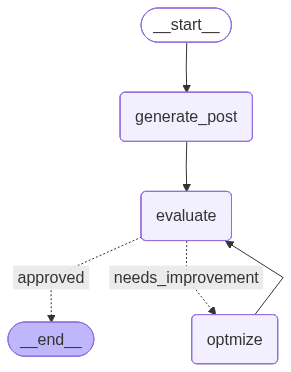

In [26]:
workflow

In [29]:
initial_state = {
    "topic": "srhberhb",
    "iteration": 1,
    "max_iteration": 5
}
result = workflow.invoke(initial_state)

In [30]:
result

{'topic': 'srhberhb',
 'post': '"SRHBERHB: The new term for when you try to type \'serious\' but your phone autocorrects it to \'sir herb\'. My life is officially a comedy of errors #SRHBERHB"',
 'evaluation': 'approved',
 'feedback': "This tweet effectively utilizes originality and humor, making it an engaging and entertaining read. The use of autocorrected 'SRHBERHB' as a play on 'serious' is clever and fresh. However, it's slightly long and might benefit from a slight trim. Nevertheless, its punchiness and potential for virality are high due to its concise and well-crafted format.",
 'iteration': 1,
 'post_histroy': [],
 'feedback_history': ["This tweet effectively utilizes originality and humor, making it an engaging and entertaining read. The use of autocorrected 'SRHBERHB' as a play on 'serious' is clever and fresh. However, it's slightly long and might benefit from a slight trim. Nevertheless, its punchiness and potential for virality are high due to its concise and well-crafted